<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 6, PatchTST vs  Informer**

In [ ]:
!pip install -q neuralforecast datasetsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.0 MB/s eta 0:00:00


Importamos lo necesario

In [ ]:
import pandas as pd
import numpy as np
from datasetsforecast.long_horizon import LongHorizon
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST, Informer
from neuralforecast.losses.pytorch import MAE

Cargamos los datos

In [ ]:
# Y_df tiene columnas [unique_id, ds, y] (ETTh2 = 7 series horarias)
Y_df, _, _ = LongHorizon.load(directory='./data', group='ETTh2')
Y_df['ds'] = pd.to_datetime(Y_df['ds'])

HORIZON = 96      # cuántos pasos predecir
INPUT_SIZE = 512  # cuánta historia ve el modelo

* Maneja split estándar de long-horizon: 70% train / 10% val / 20% test
* Mismos hiperparámetros comunes para que la comparación sea justa)
* Compara con el MAE

In [ ]:
MAX_STEPS = 500

Split temporal

In [ ]:
n_time = len(Y_df.ds.unique())
val_size = int(.1 * n_time)
test_size = int(.2 * n_time)

Modelos

In [ ]:
common = dict(
    h=HORIZON,
    input_size=INPUT_SIZE,
    loss=MAE(),
    max_steps=MAX_STEPS,
    val_check_steps=50,
    early_stop_patience_steps=3,
    batch_size=32,
    scaler_type='identity', # los datos de LongHorizon ya vienen estandarizados
    random_seed=1,
)

In [ ]:
models = [

    PatchTST(patch_len=16, stride=8, hidden_size=128,
             n_heads=4, encoder_layers=3, dropout=0.2, **common),


    Informer(hidden_size=128, n_head=4, encoder_layers=2, decoder_layers=1,
             factor=3, distil=True, dropout=0.05, **common),
]


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(models=models, freq='h')

In [ ]:
cv = nf.cross_validation(
    df=Y_df,
    val_size=val_size,
    test_size=test_size,
    n_windows=None,      # None => cubre todo el test con paso = h
)
cv = cv.reset_index()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 1.2 M  | train
------------------------------------------------------------------
1.2 M     Trainable params
3         Non-trainable params
1.2 M     Total params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Métricas

In [ ]:
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def mse(y, yhat):  return float(np.mean((y - yhat) ** 2))

In [ ]:
nombres = ['PatchTST', 'Informer']
resultados = pd.DataFrame([
    {'modelo': m, 'MAE': mae(cv['y'], cv[m]), 'MSE': mse(cv['y'], cv[m])}
    for m in nombres
]).sort_values('MSE')

In [ ]:
print(resultados.to_string(index=False))

  modelo      MAE      MSE
PatchTST 0.289770 0.141747
Informer 0.363604 0.196876


Grafico

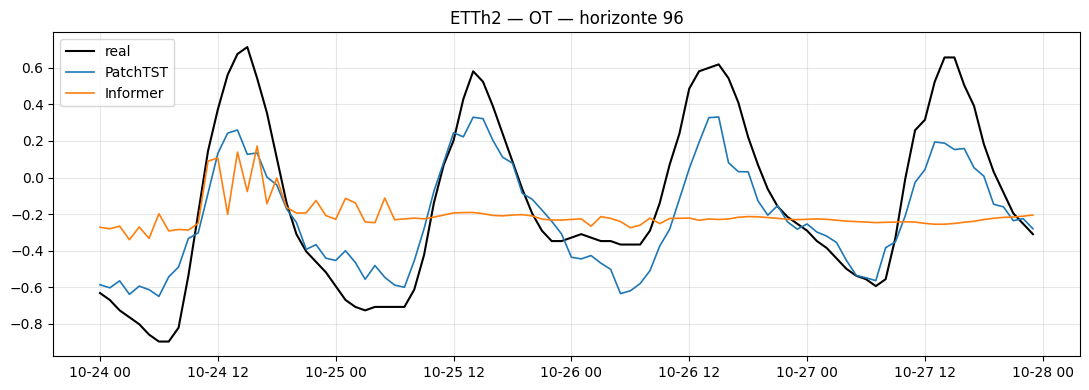

In [ ]:
import matplotlib.pyplot as plt

serie = 'OT'  # variable objetivo típica de ETT
sub = cv[cv.unique_id == serie]
corte = sub.cutoff.unique()[0]  # primera ventana del test
sub = sub[sub.cutoff == corte]

plt.figure(figsize=(11, 4))
plt.plot(sub.ds, sub.y, label='real', color='black', lw=1.5)
for m in nombres:
    plt.plot(sub.ds, sub[m], label=m, lw=1.2)
plt.title(f'ETTh2 — {serie} — horizonte {HORIZON}')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()